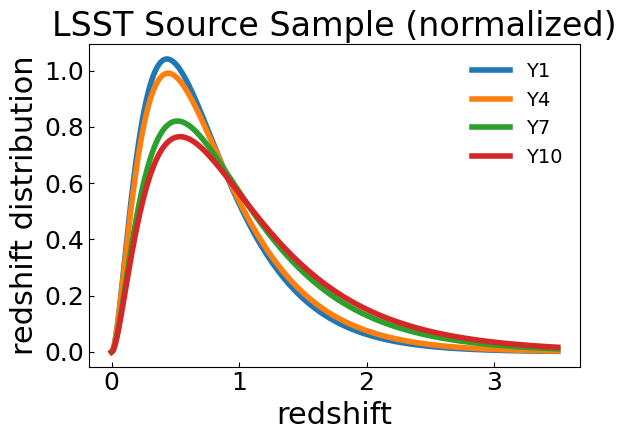

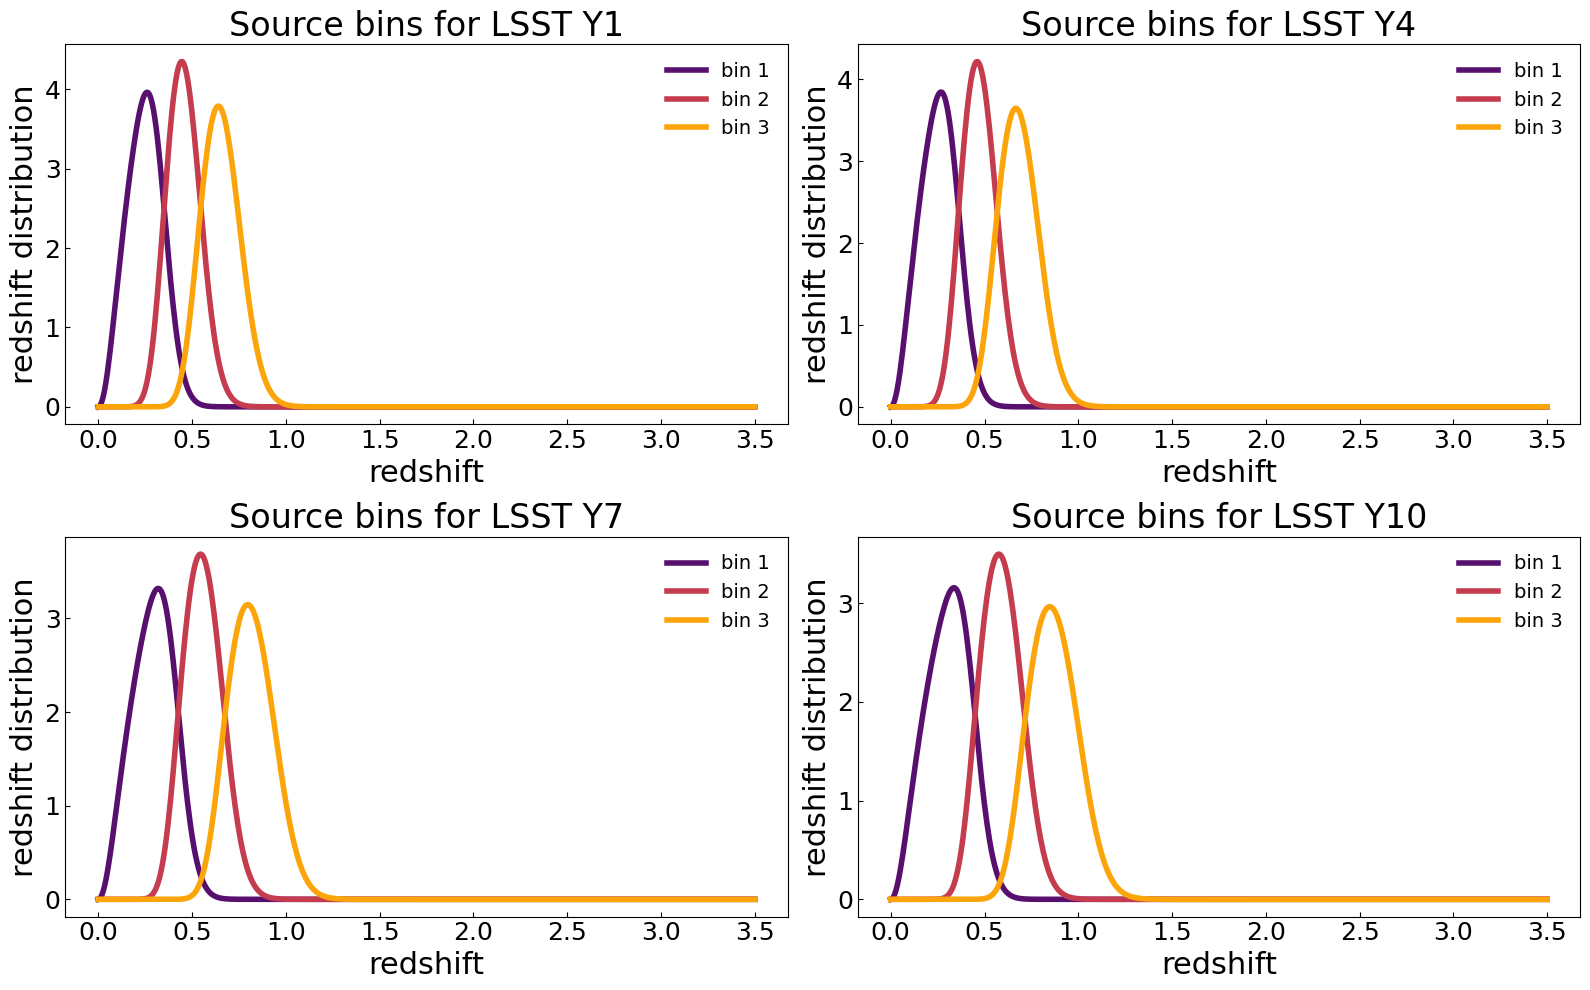

Source bin centers for Y1 (bins 1–3): [0.251, 0.456, 0.655]
Source bin centers for Y4 (bins 1–3): [0.256, 0.472, 0.682]
Source bin centers for Y7 (bins 1–3): [0.296, 0.558, 0.815]
Source bin centers for Y10 (bins 1–3): [0.309, 0.589, 0.867]


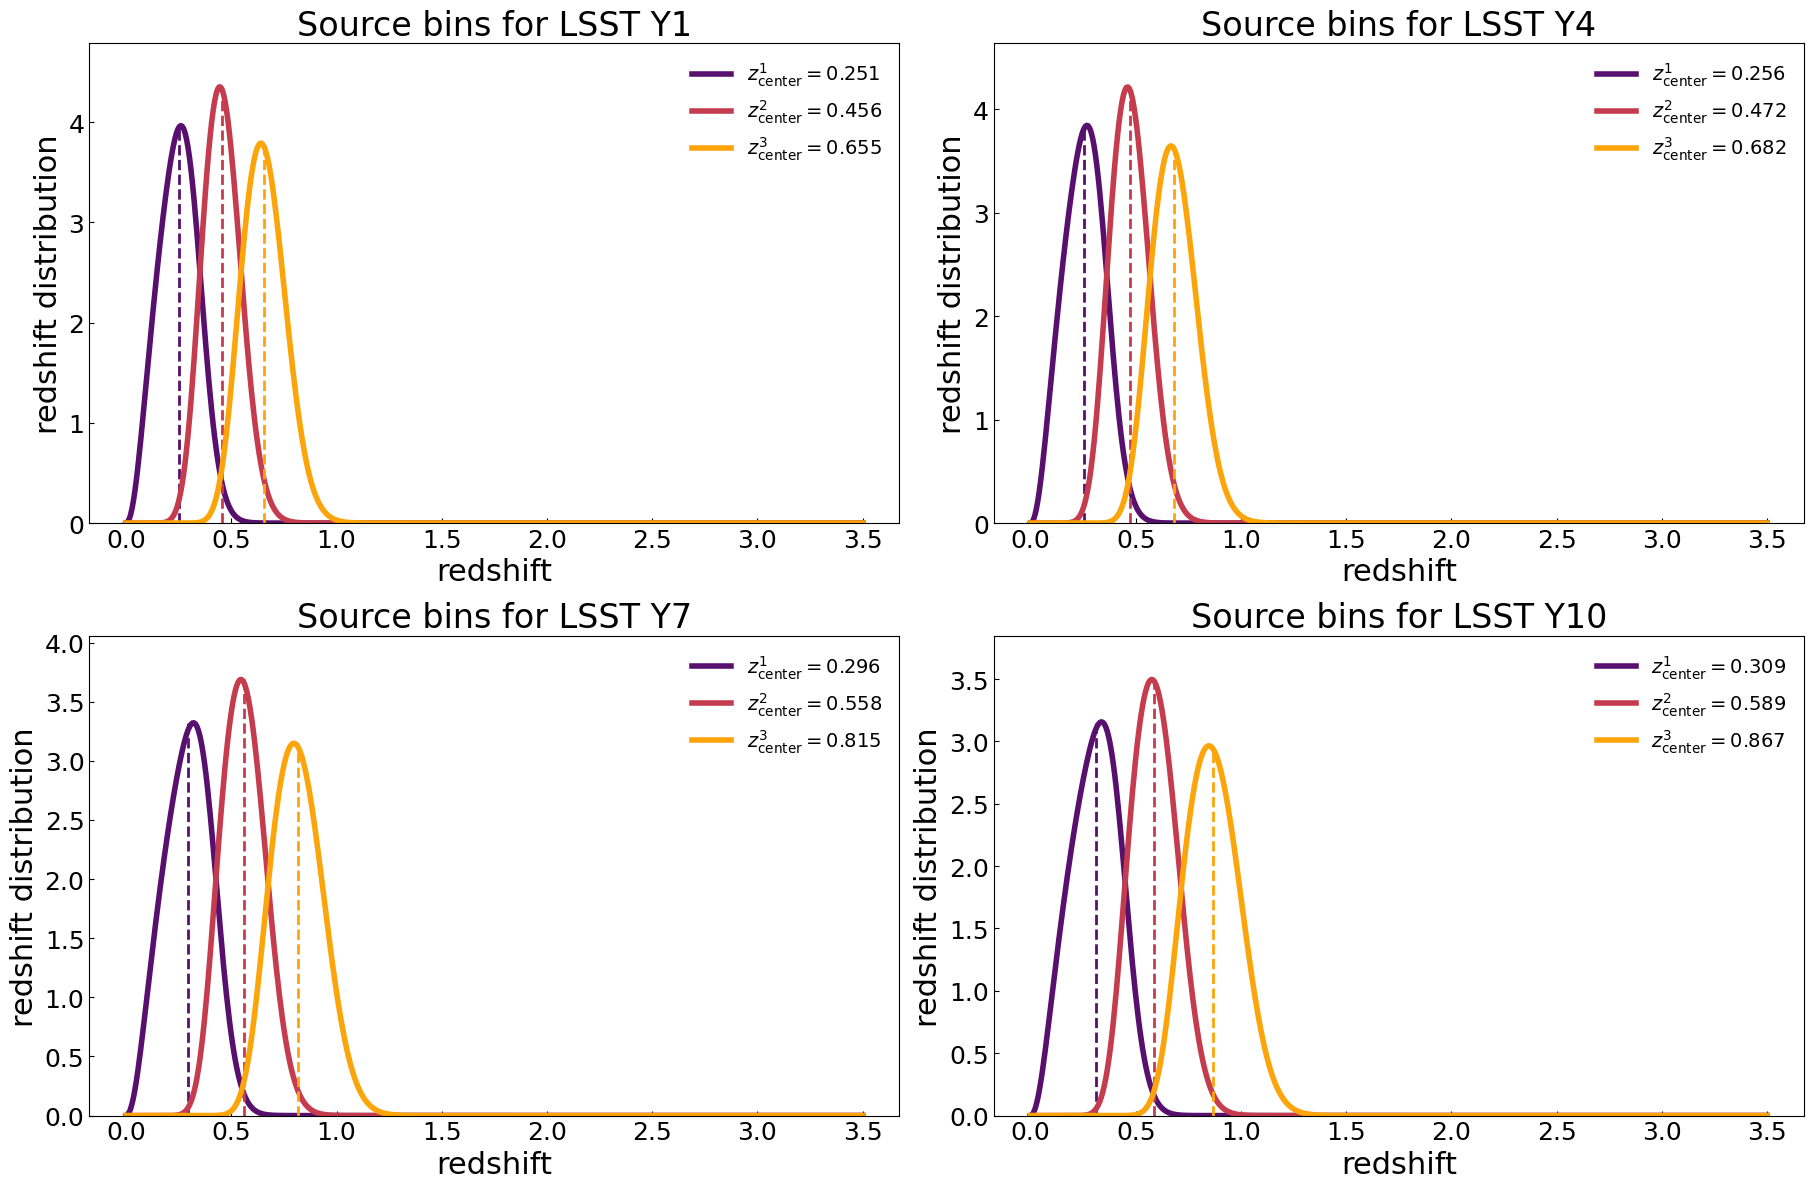

In [5]:
"""
LSST_SRD_Redshift_Distributions_and_Binning
Source sample only
Bins 1–3 only
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from lsst_galaxy_sample import LSSTGalaxySample as lsst


# ------------------------------------------------------------------
# Helper: replacement for cmr.take_cmap_colors
# ------------------------------------------------------------------
def take_cmap_colors(cmap_name, n, cmap_range=(0.0, 1.0), return_hex=True):
    cmap = plt.get_cmap(cmap_name)
    values = np.linspace(cmap_range[0], cmap_range[1], n)
    colors = cmap(values)
    if return_hex:
        return [mcolors.to_hex(c) for c in colors]
    return colors


# ------------------------------------------------------------------
# Define the redshift interval and forecast years
# ------------------------------------------------------------------
redshift_range = np.linspace(0.0, 3.5, 500)
forecast_years = ["1", "4", "7", "10"]
samples = {}

# ------------------------------------------------------------------
# Generate LSST SOURCE samples only
# ------------------------------------------------------------------
for year in forecast_years:
    init = lsst(year, redshift_range)
    samples[year] = {
        "source_nz": init.source_sample(normalized=True, save_file=True),
        "source_bins": init.source_bins(normalized=True, save_file=True),
        "source_bin_centers": init.source_bin_centers(decimal_places=3),
    }


# ------------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------------
plt.rcParams.update({
    "lines.linewidth": 3,
    "axes.labelsize": 22,
    "axes.titlesize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14
})


# ------------------------------------------------------------------
# Define colors (ONLY 3 bins)
# ------------------------------------------------------------------
colors = {
    year: take_cmap_colors("inferno", 3, cmap_range=(0.25, 0.8))
    for year in forecast_years
}


# ------------------------------------------------------------------
# Plot SOURCE redshift distributions 
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
lw = 4

year_colors = {
    "1":  "#1f77b4",  # blue
    "4":  "#ff7f0e",  # orange
    "7":  "#2ca02c",  # green
    "10": "#d62728",  # red
}

ax.plot(redshift_range, samples["1"]["source_nz"],
        label="Y1", color=year_colors["1"], lw=lw)
ax.plot(redshift_range, samples["4"]["source_nz"],
        label="Y4", color=year_colors["4"], lw=lw)
ax.plot(redshift_range, samples["7"]["source_nz"],
        label="Y7", color=year_colors["7"], lw=lw)
ax.plot(redshift_range, samples["10"]["source_nz"],
        label="Y10", color=year_colors["10"], lw=lw)

ax.set_title("LSST Source Sample (normalized)")
ax.set_xlabel("redshift")
ax.set_ylabel("redshift distribution")
ax.tick_params(direction="in")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot SOURCE tomographic bins (ONLY BINS 1–3)
# ------------------------------------------------------------------
years = ["1", "4", "7", "10"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
lw = 4

for idx, year in enumerate(years):
    ax = axes[idx]

    for bin_idx, (key, data) in enumerate(samples[year]["source_bins"].items()):
        if key >= 3:
            continue  # remove bins 4 and 5

        ax.plot(
            redshift_range,
            data,
            label=f"bin {key + 1}",
            color=colors[year][bin_idx],
            lw=lw
        )

    ax.set_xlabel("redshift")
    ax.set_ylabel("redshift distribution")
    ax.set_title(f"Source bins for LSST Y{year}")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Print SOURCE bin centers (ONLY BINS 1–3)
# ------------------------------------------------------------------
for year in years:
    centers = [
        center for key, center in samples[year]["source_bin_centers"].items()
        if key < 3
    ]
    print(f"Source bin centers for Y{year} (bins 1–3): {centers}")


# ------------------------------------------------------------------
# Plot SOURCE bins with bin centers marked (ONLY BINS 1–3)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
lw = 4

for idx, year in enumerate(years):
    ax = axes[idx]

    valid_bins = {
        key: data
        for key, data in samples[year]["source_bins"].items()
        if key < 3
    }

    global_max = max([max(data) for data in valid_bins.values()])
    ax.set_ylim(0, global_max * 1.1)

    for bin_idx, (key, data) in enumerate(valid_bins.items()):
        center = samples[year]["source_bin_centers"][key]
        max_bin_value = max(data)

        ax.axvline(
            center,
            color=colors[year][bin_idx],
            linestyle="--",
            lw=2,
            ymin=0,
            ymax=max_bin_value / (global_max * 1.1)
        )

        ax.plot(
            redshift_range,
            data,
            label=rf"$z_\mathrm{{center}}^{key+1}={center:.3f}$",
            color=colors[year][bin_idx],
            lw=lw
        )

    ax.set_xlabel("redshift")
    ax.set_ylabel("redshift distribution")
    ax.set_title(f"Source bins for LSST Y{year}")
    ax.tick_params(direction="in")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()